# NFL Coaching Career Movement Prediction

This notebook analyzes NFL coaching career trajectories and predicts whether a coach will be promoted, demoted, move sideways, or exit the league.

## ⚙️ v2 — Leakage-corrected version

Revised copy of `ML_project_final.ipynb`. Changes vs. the original:

1. **Group-aware train/test split.** The original used a random `train_test_split`. Because each coach has many seasons and labels are forward-looking, that leaked correlated rows across train/test and inflated scores. We now use `GroupShuffleSplit` on `CoachID` so no coach appears in both sets (Preprocessing cell and the 5-tier remap cell).
2. **Group-aware cross-validation.** `cross_val_score` and both `GridSearchCV`s now use `StratifiedGroupKFold` with `groups=CoachID`, so the CV estimate isn't leaky either.
3. **Bug fix:** the `min_samples_split` grid started at `1` (invalid for sklearn integers — would raise an error); it now starts at `2`.
4. **Bug fix:** the 5-tier remap now also refreshes `Next_Year` (it was stale after re-sorting), so the `Exit/Gap` gap-logic is correct.

**Expect lower — but honest — scores than the original.**

> ⚠️ Still-known limitations (intentionally *not* changed here, to keep this diff focused): `statistical_positionality` and `prev_league_churn` are engineered on the full dataset before the split (a milder form of leakage), and current-season (2025) rows are still labeled `Exit/Gap` due to right-censoring.


## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split, cross_val_score, GridSearchCV,
                                     GroupShuffleSplit, StratifiedGroupKFold)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.feature_selection import f_classif
from sklearn.inspection import permutation_importance

from imblearn.over_sampling import SMOTE, SMOTENC  # SMOTENC handles the categorical columns (Race, Tier)
from collections import Counter

import nflreadpy as nfl
import warnings
# Only silence version-churn noise from pandas/sklearn so the output stays readable.
# Substantive warnings (convergence, undefined metrics, data issues) still surface,
# rather than blanket-ignoring everything with filterwarnings('ignore').
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

print("All imports loaded successfully.")

All imports loaded successfully.


## 2. Data Loading & Team Name Mapping

In [2]:
# Load NFL team mapping
teams = nfl.load_teams()
mapping = dict(zip(teams['team_abbr'], teams['team_name']))

# Load coaching dataset and team stats
df = pd.read_stata("coach list 89-25 with race.dta")
df2 = pd.read_csv("team_stats_2003_2023.csv")

print(f"Coaching data: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Team stats: {df2.shape[0]} rows, {df2.shape[1]} columns")
df.head(3)


Coaching data: 14745 rows, 7 columns
Team stats: 672 rows, 35 columns


,Team,Year,Role,CoachName,DOB,Race,Played
0,ARI,1986,HC,G. Stallings,1935-03-02,W,0.0
1,ARI,1986,OC,J. Shofner,1935-12-18,W,1.0
2,ARI,1987,HC,G. Stallings,1935-03-02,W,0.0


In [3]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 672 entries, 0 to 671
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  672 non-null    int64  
 1   team                  672 non-null    object 
 2   wins                  672 non-null    int64  
 3   losses                672 non-null    int64  
 4   win_loss_perc         672 non-null    float64
 5   points                672 non-null    int64  
 6   points_opp            672 non-null    int64  
 7   points_diff           672 non-null    int64  
 8   mov                   352 non-null    float64
 9   g                     672 non-null    int64  
 10  total_yards           672 non-null    int64  
 11  plays_offense         672 non-null    int64  
 12  yds_per_play_offense  672 non-null    float64
 13  turnovers             672 non-null    int64  
 14  fumbles_lost          672 non-null    int64  
 15  first_down            6

## 3. Data Cleaning & Merging

In [4]:
#Translate team abbreviations to full names, accounting for franchise relocations
def get_historical_name(row):
    translations = {
        'GNB': 'GB', 'KAN': 'KC', 'NEW': 'NE', 
        'NOR': 'NO', 'SFO': 'SF', 'TAM': 'TB'
    }
    abbr = translations.get(row['Team'], row['Team'])
    year = row['Year']
    
    if abbr == 'WAS':
        if year <= 2019: return 'Washington Redskins'
        if year <= 2021: return 'Washington Football Team'
        return 'Washington Commanders'
    if abbr in ['STL', 'LA', 'LAR']:
        return 'St. Louis Rams' if year <= 2015 else 'Los Angeles Rams'
    if abbr in ['SD', 'LAC']:
        return 'San Diego Chargers' if year <= 2016 else 'Los Angeles Chargers'
    if abbr in ['OAK', 'LV']:
        return 'Oakland Raiders' if year <= 2019 else 'Las Vegas Raiders'
    return mapping.get(abbr)


In [5]:
# Create unique coach ID and experience counter
df['CoachID'] = df['CoachName'] + "_" + df['DOB'].astype(str)
df = df.sort_values(['CoachID', 'Year'])
df['Experience'] = df.groupby('CoachID').cumcount()

# Filter to 2003+ and standardize team names
df_filtered = df[df['Year'] >= 2003].copy()
df_filtered['FullTeamName'] = df_filtered.apply(get_historical_name, axis=1)

# Merge coaching data with team stats
merged_df = pd.merge(
    df_filtered, df2,
    left_on=['Year', 'FullTeamName'], right_on=['year', 'team'],
    how='left'
).drop(columns=['year', 'team'])

print(f"Missing FullTeamNames: {merged_df['FullTeamName'].isnull().sum()}")
print(f"Merged dataset: {merged_df.shape}")


Missing FullTeamNames: 0
Merged dataset: (9733, 43)


In [6]:
# Convert ties to half-wins/half-losses and drop the ties column
has_tie = merged_df['ties'] > 0
merged_df.loc[has_tie, 'wins'] += merged_df['ties'] * 0.5
merged_df.loc[has_tie, 'losses'] += merged_df['ties'] * 0.5
merged_df = merged_df.drop(columns=['ties'])

# Drop rows with missing coach names
merged_df['CoachName'] = merged_df['CoachName'].replace('', pd.NA)
merged_df = merged_df.dropna(subset=['CoachName'])

print(f"Dataset size after cleaning: {len(merged_df)} rows")
print(f"Unique coaches: {merged_df['CoachID'].nunique()}")


Dataset size after cleaning: 9725 rows
Unique coaches: 1324


## 4. Feature Engineering

### 4a. Role Hierarchy, Movement Labels & Race Encoding

In [7]:
# Define 3-tier coaching hierarchy
original_hierarchy = {
    'HC': 3,
    'OC': 2, 'DC': 2, 'ST': 2,
    'QB': 1,
    'DL': 1, 'WR': 1, 'DB': 1, 'RB': 1,
    'LB': 1, 'OL': 1, 'TE': 1
}

merged_df['Tier'] = merged_df['Role'].map(original_hierarchy)

# Calculate forward-looking movement labels
merged_df = merged_df.sort_values(['CoachID', 'Year'])
merged_df['Next_Tier'] = merged_df.groupby('CoachID')['Tier'].shift(-1)
merged_df['Next_Year'] = merged_df.groupby('CoachID')['Year'].shift(-1)

def calculate_forward_movement(row):
    if pd.isna(row['Next_Tier']) or (row['Next_Year'] - row['Year'] > 1):
        return 'Exit/Gap'
    if row['Next_Tier'] > row['Tier']:
        return 'Promotion'
    elif row['Next_Tier'] < row['Tier']:
        return 'Demotion'
    return 'Sideways'

merged_df['Movement'] = merged_df.apply(calculate_forward_movement, axis=1)

print("Original Movement distribution:")
print(merged_df['Movement'].value_counts())


Original Movement distribution:
Movement
Sideways     6988
Exit/Gap     1940
Promotion     496
Demotion      301
Name: count, dtype: int64


In [8]:
# 2025 demographics snapshot (before filtering)
df_2025 = merged_df[merged_df['Year'] == 2025]
label_map = {'W': 'White', 'B': 'Black', 'M': 'Mixed/Other', '0': 'Unknown'}
print("--- 2025 Coaching Demographics ---")
for race_val, count in df_2025['Race'].value_counts().items():
    pct = count / len(df_2025) * 100
    print(f"{label_map.get(race_val, race_val)}: {count} ({pct:.1f}%)")

# Keep only White (W) and Black (B) coaches, encode as 0/1
merged_df = merged_df[merged_df['Race'].isin(['W', 'B'])].copy()
merged_df['Race'] = merged_df['Race'].map({'W': 0, 'B': 1})

print(f"\nAfter race filtering: {len(merged_df)} rows")
print(merged_df['Race'].value_counts().rename({0: 'White', 1: 'Black'}))


--- 2025 Coaching Demographics ---
White: 250 (58.4%)
Black: 177 (41.4%)
Mixed/Other: 1 (0.2%)

After race filtering: 9606 rows
Race
White    6352
Black    3254
Name: count, dtype: int64


### 4b. Statistical Positionality Score

In [9]:
#Define relevant statistics for each position
relevant_stats = {
    'HC': ['win_loss_perc', 'mov', 'points_diff', 'wins'],
    'OC': ['points', 'score_pct', 'exp_pts_tot'],
    'DC': ['points_opp', 'turnover_pct'],
    'QB': ['pass_yds', 'pass_td', 'pass_cmp_perc', 'pass_int', 'pass_fd'],
    'RB': ['rush_yds', 'rush_td', 'rush_yds_per_att', 'rush_fd'],
    'WR': ['pass_yds', 'pass_td', 'pass_fd'],
    'TE': ['pass_yds', 'pass_td', 'pass_fd'],
    'OL': ['rush_yds_per_att', 'rush_att', 'penalties'],
    'DL': ['points_opp'], 'LB': ['points_opp'], 
    'DB': ['points_opp', 'pass_int'],
}

def calculate_statistical_positionality(df):
    df['statistical_positionality'] = 0.0
    inverse_stats = {'points_opp', 'pass_int', 'penalties', 'penalties_yds'}
    
    for (year, role), group in df.groupby(['Year', 'Role']):
        if role not in relevant_stats:
            continue
        stats_to_check = [s for s in relevant_stats[role] if s in group.columns]
        if not stats_to_check:
            continue
        
        percentile_ranks = []
        for stat in stats_to_check:
            ascending = stat not in inverse_stats
            percentile_ranks.append(group[stat].rank(pct=True, ascending=ascending))
        
        avg_percentile = pd.concat(percentile_ranks, axis=1).mean(axis=1)
        df.loc[avg_percentile.index, 'statistical_positionality'] = avg_percentile
    return df

merged_df = calculate_statistical_positionality(merged_df)
print(merged_df[['CoachName', 'Year', 'Role', 'statistical_positionality']].sample(5))


          CoachName  Year Role  statistical_positionality
2616        D. Webb  2025   QB                        NaN
7511  R. Chudzinski  2010   TE                   0.930108
7507  R. Chudzinski  2006   OC                   0.133333
9157     T. Rathman  2019   RB                   0.781250
2358     D. Pitcher  2020   QB                   0.375000


### 4c. League-Wide Churn Rate Feature

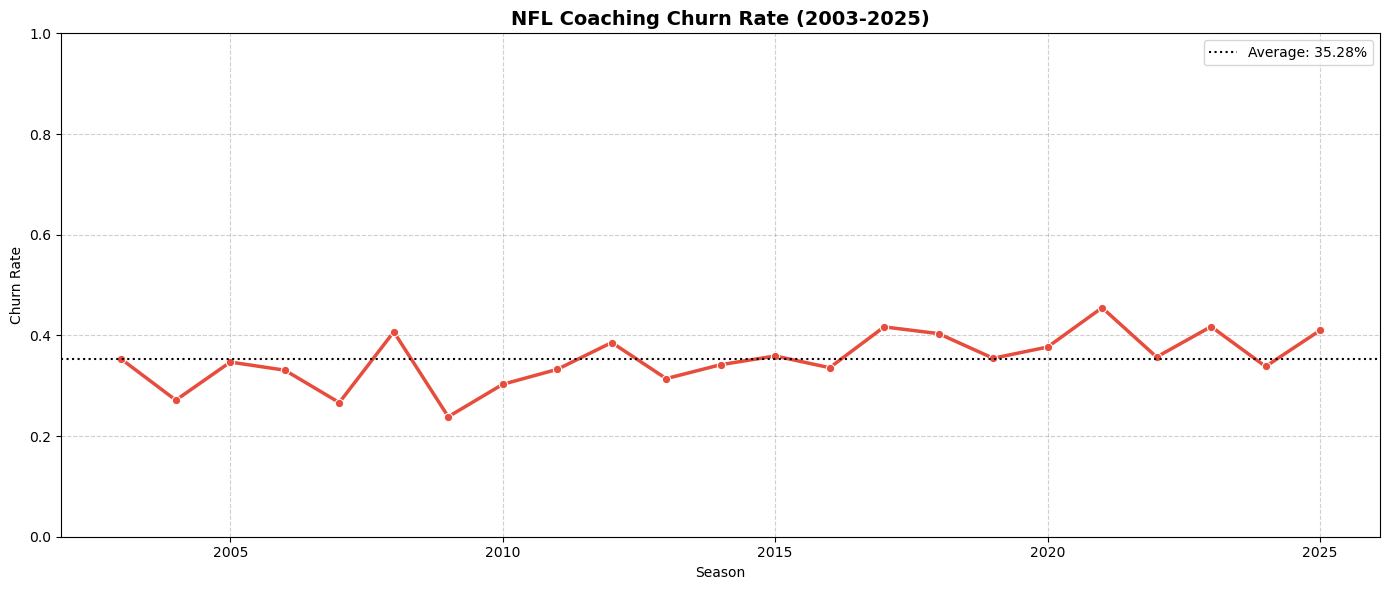

In [10]:
def calculate_seasonal_churn(df):
    churn_data = []
    df_sorted = df.sort_values(['FullTeamName', 'Role', 'Year'])
    years = sorted(df_sorted['Year'].unique())
    
    for i in range(len(years) - 1):
        current = df_sorted[df_sorted['Year'] == years[i]][['CoachID', 'FullTeamName', 'Role']]
        next_yr = df_sorted[df_sorted['Year'] == years[i+1]][['CoachID', 'FullTeamName', 'Role']]
        returned = pd.merge(current, next_yr, on=['CoachID', 'FullTeamName', 'Role'])
        
        total = len(current)
        persistence = len(returned) / total if total > 0 else 0
        churn_data.append({
            'Year': years[i], 'Next_Year': years[i+1],
            'Churn_Rate': 1 - persistence, 'Total_Coaches': total, 'Returned': len(returned)
        })
    return pd.DataFrame(churn_data)

churn_df = calculate_seasonal_churn(merged_df)

# Map previous year's churn as a feature
churn_lookup = churn_df[['Next_Year', 'Churn_Rate']].copy()
churn_lookup['Target_Year'] = churn_lookup['Next_Year'] + 1
churn_lookup = churn_lookup.rename(columns={'Churn_Rate': 'prev_league_churn'})

merged_df = pd.merge(
    merged_df, churn_lookup[['Target_Year', 'prev_league_churn']],
    left_on='Year', right_on='Target_Year', how='left'
).drop(columns=['Target_Year'])
merged_df['prev_league_churn'] = merged_df['prev_league_churn'].fillna(merged_df['prev_league_churn'].mean())

# Visualization
plt.figure(figsize=(14, 6))
sns.lineplot(data=churn_df, x='Year', y='Churn_Rate', marker='o', color='#e74c3c', linewidth=2.5)
mean_churn = churn_df['Churn_Rate'].mean()
plt.axhline(mean_churn, color='black', linestyle=':', label=f'Average: {mean_churn:.2%}')
plt.title('NFL Coaching Churn Rate (2003-2025)', fontsize=14, fontweight='bold')
plt.ylabel('Churn Rate'); plt.xlabel('Season'); plt.ylim(0, 1)
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6); plt.tight_layout(); plt.show()


In [11]:
# ---- Leak-free feature engineering (Option A: train-fit / test-transform) ----
# `statistical_positionality` and `prev_league_churn` are POOLED statistics. Computing them
# over the full dataset (as the cells above do, for EDA) lets test rows influence train rows'
# values and vice-versa. These helpers recompute both from TRAINING rows only and project the
# result onto the held-out rows, so reported test scores carry no train/test contamination.
# (They reuse `relevant_stats` and `calculate_seasonal_churn` defined above.)
# Note: GridSearchCV's inner folds still share the train-computed features — a minor, contained
# impurity that affects only hyperparameter selection, not the final held-out test score.

_INVERSE_STATS = {'points_opp', 'pass_int', 'penalties', 'penalties_yds'}

def _ecdf_percentile(values, reference, ascending):
    """Percentile of each value against the (training) reference distribution."""
    ref = np.sort(np.asarray(reference, dtype=float))
    ref = ref[~np.isnan(ref)]
    vals = np.asarray(values, dtype=float)
    if ref.size == 0:
        return np.full(vals.shape, np.nan)
    pct = np.searchsorted(ref, vals, side='right') / ref.size
    pct = np.where(np.isnan(vals), np.nan, pct)
    return pct if ascending else 1.0 - pct

def _positionality_train_only(train_df, test_df):
    # Reference distribution for each (Year, Role) comes from TRAIN rows only.
    train_df['statistical_positionality'] = 0.0
    test_df['statistical_positionality'] = 0.0
    for (year, role), ref_group in train_df.groupby(['Year', 'Role']):
        if role not in relevant_stats:
            continue
        stats = [s for s in relevant_stats[role] if s in ref_group.columns]
        if not stats:
            continue
        for d in (train_df, test_df):
            mask = (d['Year'] == year) & (d['Role'] == role)
            if not mask.any():
                continue
            ranks = [_ecdf_percentile(d.loc[mask, s], ref_group[s], s not in _INVERSE_STATS)
                     for s in stats]
            d.loc[mask, 'statistical_positionality'] = np.nanmean(np.vstack(ranks), axis=0)
    return train_df, test_df

def _churn_train_only(train_df, test_df):
    churn = calculate_seasonal_churn(train_df)                              # estimated from TRAIN coaches only
    year_to_churn = dict(zip(churn['Next_Year'] + 1, churn['Churn_Rate']))  # same lag as the EDA version
    fill = np.mean(list(year_to_churn.values())) if year_to_churn else 0.0  # fill value also train-only
    for d in (train_df, test_df):
        d['prev_league_churn'] = d['Year'].map(year_to_churn).fillna(fill)
    return train_df, test_df

def add_train_only_features(train_df, test_df):
    """Recompute the two pooled features from training rows only; return updated copies."""
    train_df, test_df = _positionality_train_only(train_df, test_df)
    train_df, test_df = _churn_train_only(train_df, test_df)
    return train_df, test_df

print("Leak-free feature helpers defined: add_train_only_features(train_df, test_df)")

Leak-free feature helpers defined: add_train_only_features(train_df, test_df)


## 5. Exploratory Data Analysis

In [12]:
merged_df.describe()


,Year,DOB,Race,Played,Experience,wins,losses,win_loss_perc,points,points_opp,...,penalties_yds,pen_fd,score_pct,turnover_pct,exp_pts_tot,Tier,Next_Tier,Next_Year,statistical_positionality,prev_league_churn
count,9606.000000,9606,9606.000000,9606.000000,9606.000000,8384.000000,8384.000000,8384.000000,8384.000000,8384.000000,...,8384.000000,8384.000000,8384.000000,8384.000000,8384.000000,9606.000000,8338.000000,8338.000000,8478.000000,9606.000000
mean,2014.629815,1966-11-13 15:21:46.433479088,0.338747,0.292109,8.881324,8.089695,8.054151,0.501338,359.327409,358.755725,...,850.070253,27.970301,34.166400,12.547555,-34.072402,1.393088,1.419525,2015.141401,0.468979,0.350858
min,2003.000000,1927-01-24 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,168.000000,201.000000,...,415.000000,9.000000,16.400000,4.000000,-358.270000,1.000000,1.000000,2003.000000,0.000000,0.238342
25%,2009.000000,1958-06-22 00:00:00,0.000000,0.000000,3.000000,6.000000,6.000000,0.375000,306.000000,317.000000,...,752.000000,23.000000,29.400000,10.200000,-121.175000,1.000000,1.000000,2009.000000,0.250000,0.332487
50%,2015.000000,1966-10-15 00:00:00,0.000000,0.000000,7.000000,8.000000,8.000000,0.500000,359.000000,358.000000,...,853.000000,28.000000,34.000000,12.400000,-39.550000,1.000000,1.000000,2015.000000,0.476562,0.350858
75%,2021.000000,1976-03-09 00:00:00,1.000000,1.000000,14.000000,10.000000,10.000000,0.625000,406.000000,398.000000,...,941.250000,33.000000,38.800000,14.800000,52.610000,2.000000,2.000000,2021.000000,0.690411,0.385787
max,2026.000000,1999-04-02 00:00:00,1.000000,1.000000,43.000000,16.000000,16.000000,1.000000,606.000000,519.000000,...,1358.000000,50.000000,52.700000,25.000000,298.140000,3.000000,3.000000,2026.000000,1.000000,0.454988
std,6.901430,NaN,0.473308,0.454756,7.446542,3.083282,3.086914,0.191180,72.136077,57.602371,...,145.952345,7.259456,6.735813,3.213910,120.770877,0.629626,0.643893,6.621307,0.281645,0.049499


In [13]:
merged_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9606 entries, 0 to 9605
Data columns (total 48 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Team                       9606 non-null   object        
 1   Year                       9606 non-null   int16         
 2   Role                       9606 non-null   object        
 3   CoachName                  9606 non-null   object        
 4   DOB                        9606 non-null   datetime64[ns]
 5   Race                       9606 non-null   int64         
 6   Played                     9606 non-null   float64       
 7   CoachID                    9606 non-null   object        
 8   Experience                 9606 non-null   int64         
 9   FullTeamName               9606 non-null   object        
 10  wins                       8384 non-null   float64       
 11  losses                     8384 non-null   float64       
 12  win_lo

### 5a. Feature Selection (F-Scores)

In [14]:
numerical_features = list(merged_df.select_dtypes(include=['float64', 'int64', 'int16']).columns)

analysis_df = merged_df[merged_df['Movement'] != 'Exit/Gap'].copy()
f_results = {}
for col in numerical_features:
    temp = analysis_df[[col, 'Movement']].dropna()
    if len(temp) > 1 and temp['Movement'].nunique() > 1:
        f_val, p_val = f_classif(temp[[col]], temp['Movement'])
        f_results[col] = f_val[0]

print("Ranked F-Scores for Numerical Features:")
print(pd.Series(f_results).sort_values(ascending=False))


Ranked F-Scores for Numerical Features:
Next_Tier                    492.276102
Tier                         301.511523
wins                          75.520035
win_loss_perc                 74.095192
losses                        72.358530
points_diff                   67.699669
statistical_positionality     52.824600
points                        42.965084
mov                           40.894860
score_pct                     40.024707
points_opp                    36.399549
pass_net_yds_per_att          28.777124
rush_td                       27.864832
total_yards                   27.667171
rush_att                      26.137953
exp_pts_tot                   25.602009
turnovers                     24.560127
turnover_pct                  24.442787
first_down                    24.180927
yds_per_play_offense          23.036002
rush_fd                       21.300450
Race                          20.790316
rush_yds                      19.717612
pass_int                      19.460325


### 5b. Movement by Role & Tier Visualizations

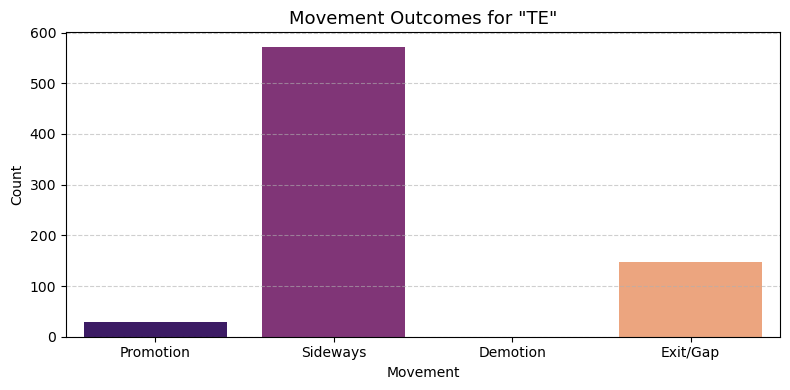

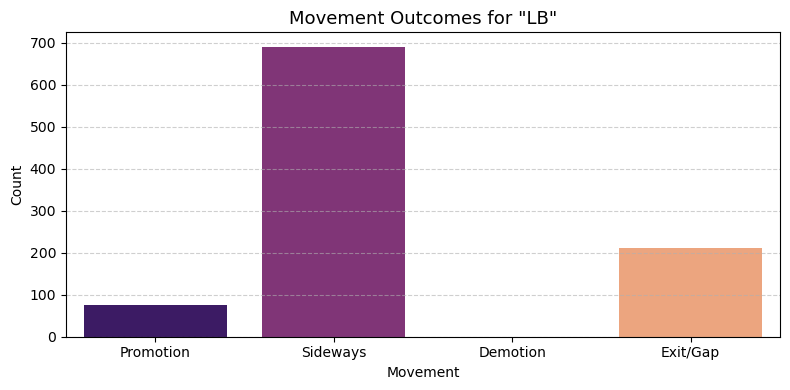

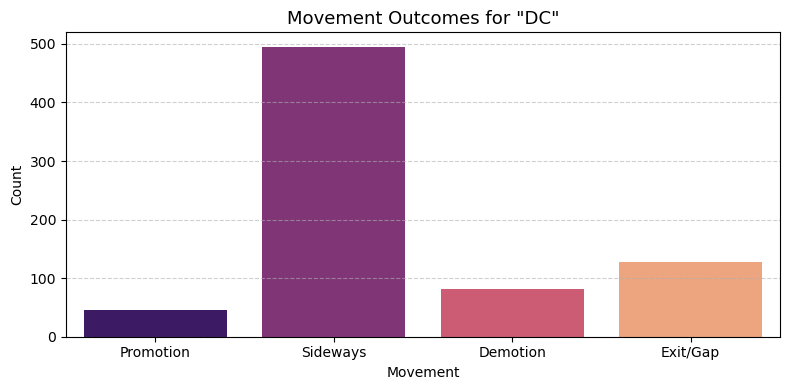

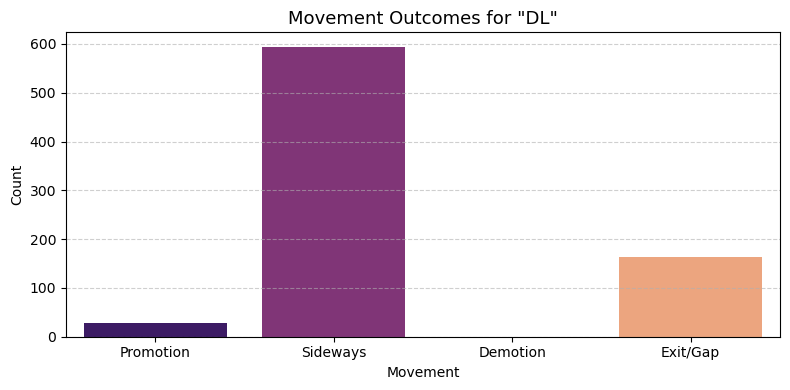

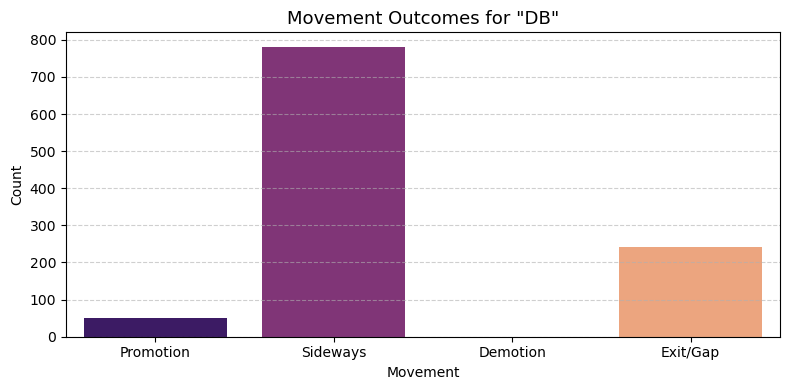

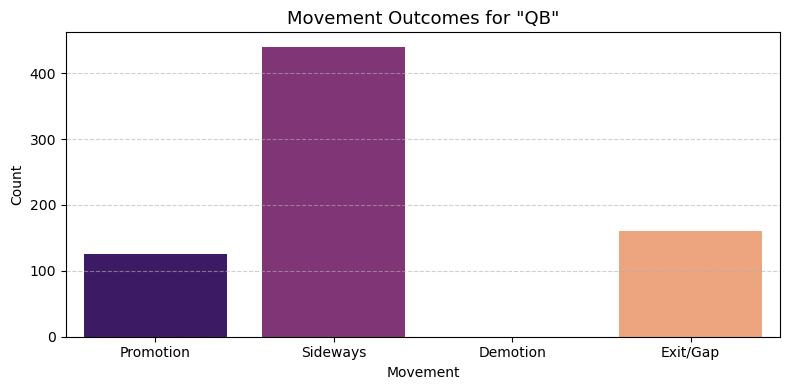

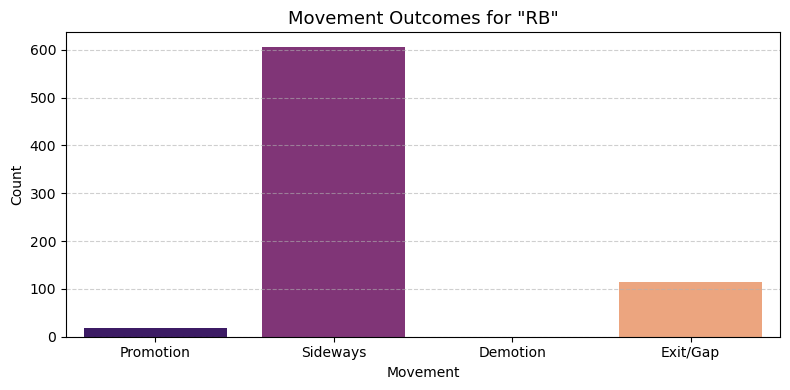

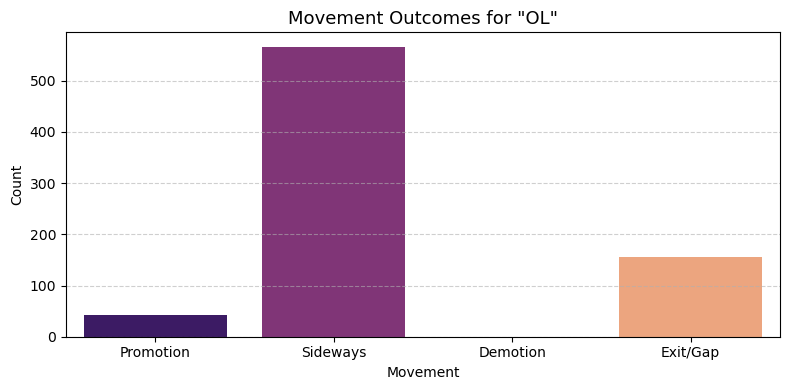

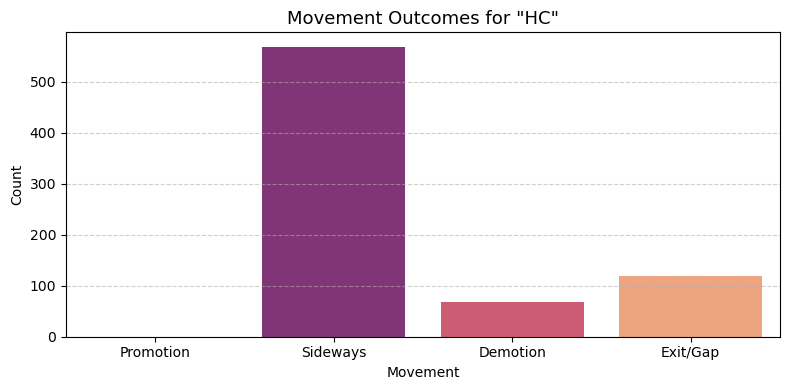

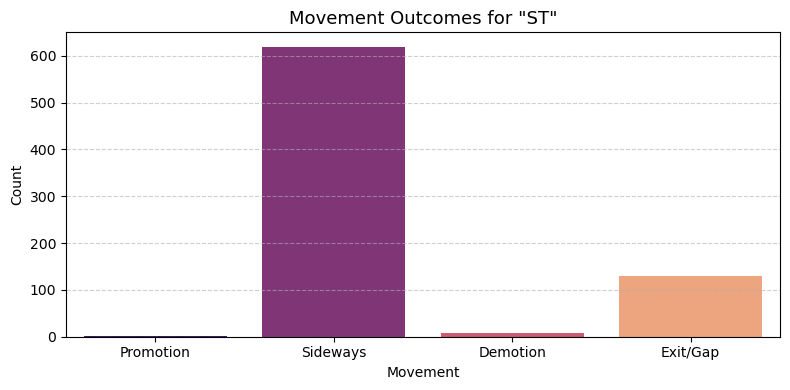

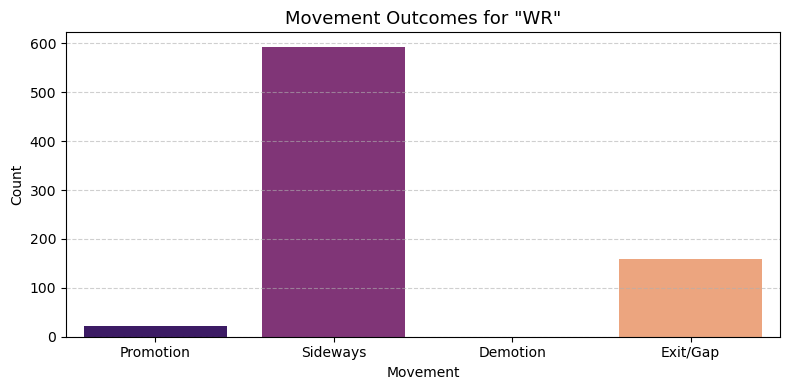

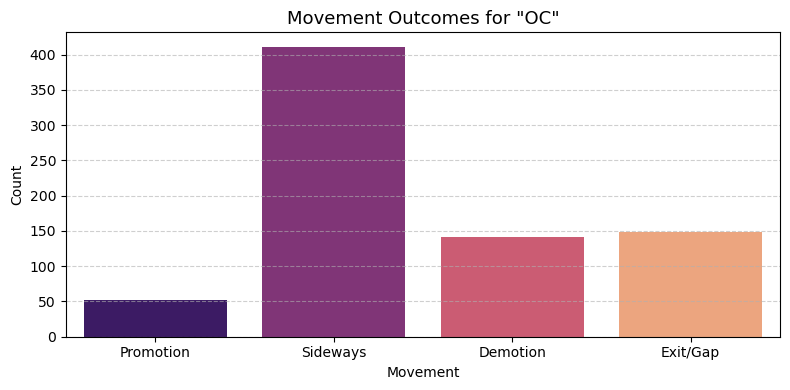

In [15]:
# Movement distribution by role
for role in merged_df['Role'].unique():
    role_df = merged_df[merged_df['Role'] == role]
    if role_df.empty:
        continue
    plt.figure(figsize=(8, 4))
    sns.countplot(data=role_df, x='Movement',
                  order=['Promotion', 'Sideways', 'Demotion', 'Exit/Gap'], palette='magma')
    plt.title(f'Movement Outcomes for "{role}"', fontsize=13)
    plt.xlabel('Movement'); plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.6); plt.tight_layout(); plt.show()


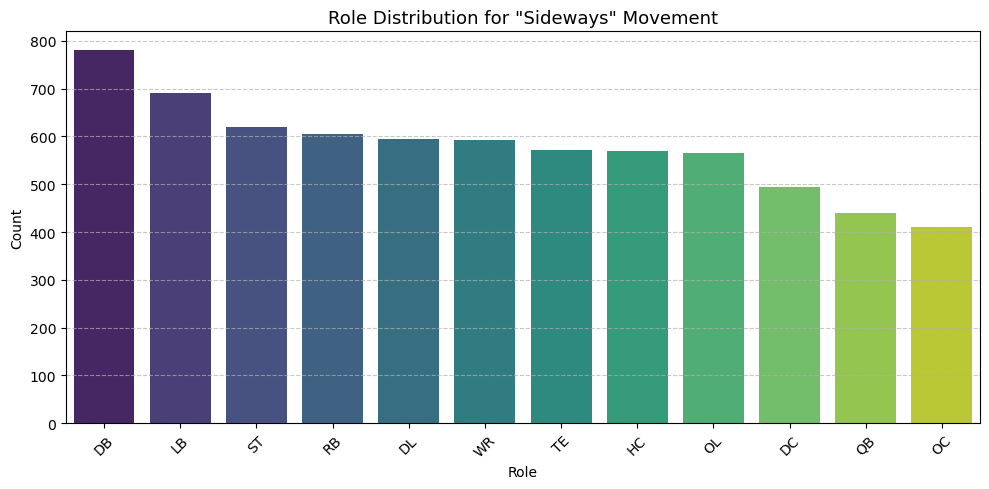

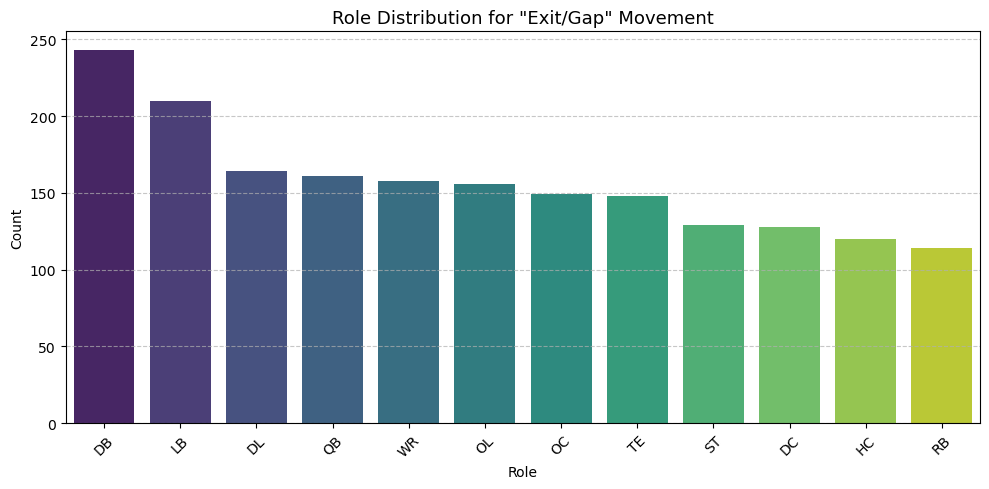

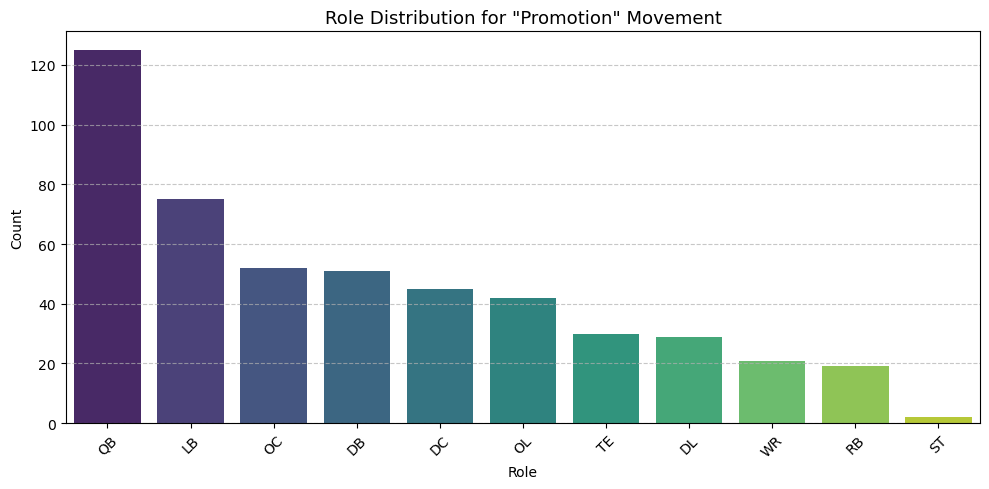

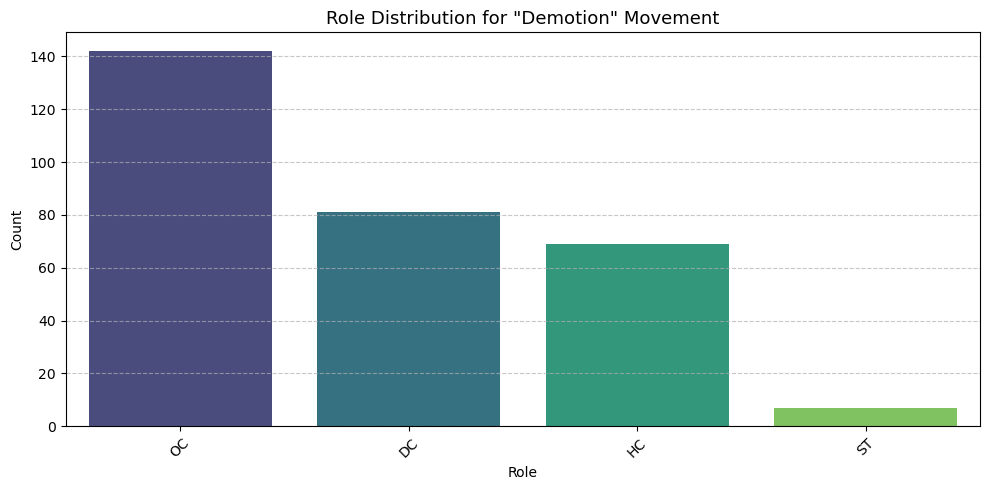

In [16]:
# Role distribution by movement category
for category in merged_df['Movement'].unique():
    cat_df = merged_df[merged_df['Movement'] == category]
    if cat_df.empty:
        continue
    plt.figure(figsize=(10, 5))
    sns.countplot(data=cat_df, x='Role', order=cat_df['Role'].value_counts().index, palette='viridis')
    plt.title(f'Role Distribution for "{category}" Movement', fontsize=13)
    plt.xlabel('Role'); plt.ylabel('Count'); plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7); plt.tight_layout(); plt.show()


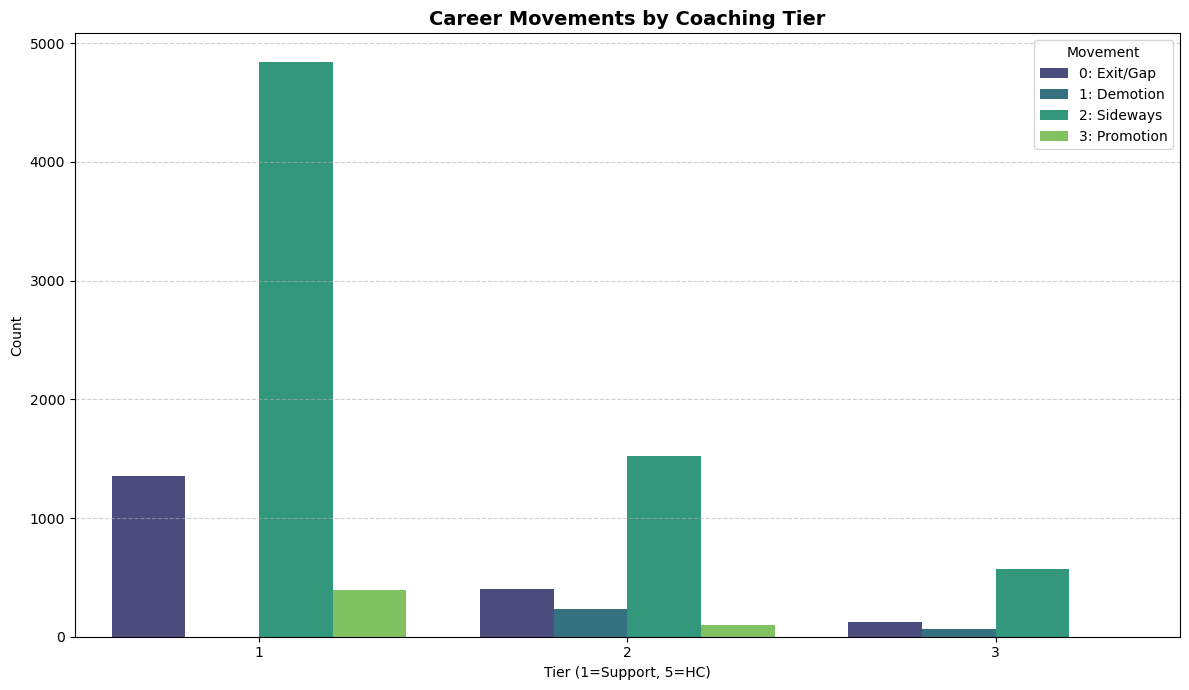

In [17]:
# Movement counts by tier
rank = {'Promotion': 3, 'Sideways': 2, 'Demotion': 1, 'Exit/Gap': 0}
merged_df['Movement_Num'] = merged_df['Movement'].map(rank)

plt.figure(figsize=(12, 7))
sns.countplot(data=merged_df, x='Tier', hue='Movement_Num', palette='viridis')
plt.title('Career Movements by Coaching Tier', fontsize=14, fontweight='bold')
plt.xlabel('Tier (1=Support, 5=HC)'); plt.ylabel('Count')
plt.legend(title='Movement', labels=['0: Exit/Gap', '1: Demotion', '2: Sideways', '3: Promotion'])
plt.grid(axis='y', linestyle='--', alpha=0.6); plt.tight_layout(); plt.show()


## 6. Preprocessing & Model Training



In [18]:
# Define features and target
features = ['Race', 'Tier', 'wins', 'points_diff', 'score_pct', 'mov',
            'statistical_positionality', 'Experience', 'prev_league_churn']

# Drop the right-censored final season before modeling. Those rows have no observable
# "next year", so calculate_forward_movement defaulted them to Exit/Gap even though most
# of those coaches did not actually leave. Labels for every earlier season were computed
# while the final season was still present (via shift(-1)), so they remain valid — we only
# remove the unobservable final-season rows themselves.
last_season = merged_df['Year'].max()
model_df = merged_df[merged_df['Year'] < last_season].copy()
print(f"Dropped {len(merged_df) - len(model_df)} right-censored rows from season {last_season}.")

# --- Group-aware train/test split (fixes the original random-split leakage) ---
# Labels are forward-looking and the same coach recurs across seasons, so a random
# split scatters one coach across train AND test. We split on CoachID so that no
# coach appears in both sets.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, model_df['Movement'], groups=model_df['CoachID']))

# Slice the FULL rows (not just `features`) so the leak-free helper can see Year/Role/stats,
# then recompute statistical_positionality + prev_league_churn from TRAIN rows only.
train_df, test_df = add_train_only_features(model_df.iloc[train_idx].copy(),
                                            model_df.iloc[test_idx].copy())

X_train, y_train = train_df[features], train_df['Movement']
X_test,  y_test  = test_df[features],  test_df['Movement']
groups_train = train_df['CoachID']   # used for group-aware cross-validation below

# Cross-validation strategy reused everywhere below: respects groups AND stratifies by class
cv_strategy = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Sanity check: zero coach overlap between train and test
overlap = set(train_df['CoachID']) & set(test_df['CoachID'])
print(f"Coaches in both train & test (should be 0): {len(overlap)}")
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"\nMissing values in training set:\n{X_train.isnull().sum()}")
print(f"\nClass distribution (train):\n{y_train.value_counts()}")

Dropped 381 right-censored rows from season 2026.
Coaches in both train & test (should be 0): 0
Training set: (7352, 9), Test set: (1873, 9)

Missing values in training set:
Race                            0
Tier                            0
wins                          671
points_diff                   671
score_pct                     671
mov                          3889
statistical_positionality     623
Experience                      0
prev_league_churn               0
dtype: int64

Class distribution (train):
Movement
Sideways     5530
Exit/Gap     1198
Promotion     385
Demotion      239
Name: count, dtype: int64


/var/folders/y5/0nclc89s67qb_6vk8r4sym0c0000gn/T/ipykernel_3194/3767980946.py:39: RuntimeWarning: Mean of empty slice
  d.loc[mask, 'statistical_positionality'] = np.nanmean(np.vstack(ranks), axis=0)


### 6a. Define the Preprocessor 




In [19]:
# All features in our set are numerical (Race and Tier are encoded as ints)
numerical_features_list = features  # all features are numeric

# Preprocessing pipeline for numerical features:
# Step 1: Impute missing values with the MEDIAN (robust to outliers)
# Step 2: Standardize features to zero mean and unit variance
numerical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# ColumnTransformer applies the pipeline to the correct columns
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features_list)
])

print("Preprocessor defined:")
print(preprocessor)


Preprocessor defined:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Race', 'Tier', 'wins', 'points_diff',
                                  'score_pct', 'mov',
                                  'statistical_positionality', 'Experience',
                                  'prev_league_churn'])])


### 6b. Baseline Model Comparison


========================= RANDOM FOREST =========================
              precision    recall  f1-score   support

    Demotion       0.28      0.08      0.13        60
    Exit/Gap       0.33      0.14      0.19       303
   Promotion       0.15      0.02      0.03       106
    Sideways       0.76      0.94      0.84      1404

    accuracy                           0.73      1873
   macro avg       0.38      0.29      0.30      1873
weighted avg       0.64      0.73      0.67      1873

CV Macro-F1: 0.3008 ± 0.0088


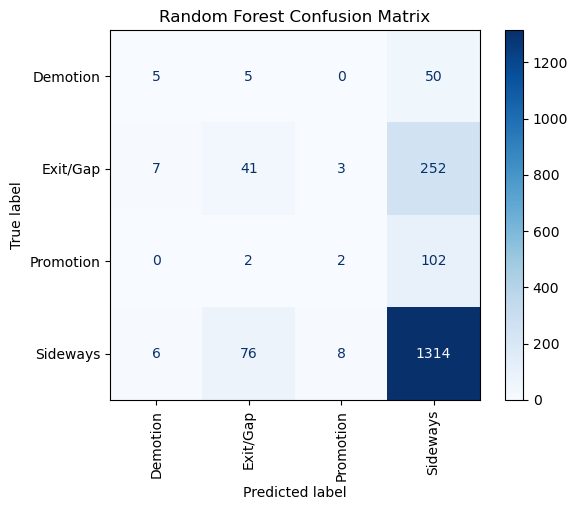

Overall Accuracy: 72.72%

Accuracy by Race (0=White, 1=Black):
Race
0    0.7247
1    0.7339
Name: Correct, dtype: float64

Random Forest Bias Summary (% of errors):


Error_Type,Optimistic,Pessimistic
Race,,
0,59.47,40.53
1,71.32,28.68



Top 3 Mispredictions for Black Coaches (Race=1):
Actual     Predicted
Exit/Gap   Sideways     82
Promotion  Sideways     24
Sideways   Exit/Gap     14
dtype: int64

========================= DECISION TREE =========================
              precision    recall  f1-score   support

    Demotion       0.18      0.20      0.19        60
    Exit/Gap       0.23      0.26      0.25       303
   Promotion       0.09      0.08      0.09       106
    Sideways       0.77      0.75      0.76      1404

    accuracy                           0.61      1873
   macro avg       0.32      0.32      0.32      1873
weighted avg       0.62      0.61      0.62      1873

CV Macro-F1: 0.3193 ± 0.0071


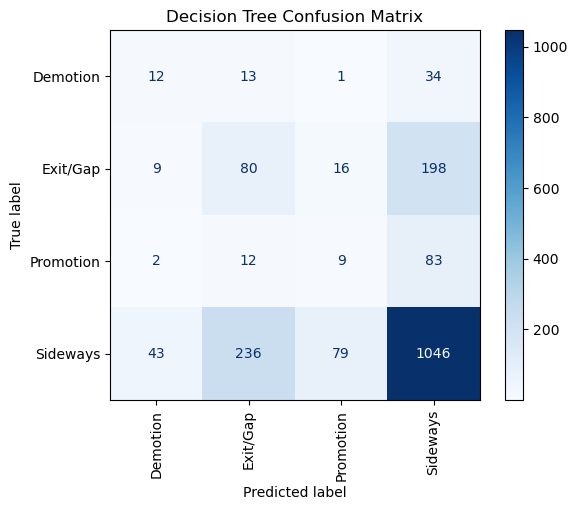

Overall Accuracy: 61.24%

Accuracy by Race (0=White, 1=Black):
Race
0    0.5991
1    0.6477
Name: Correct, dtype: float64

Decision Tree Bias Summary (% of errors):


Error_Type,Optimistic,Pessimistic
Race,,
0,44.32,55.68
1,52.78,47.22



Top 3 Mispredictions for Black Coaches (Race=1):
Actual     Predicted
Exit/Gap   Sideways     67
Sideways   Exit/Gap     53
Promotion  Sideways     22
dtype: int64

========================= NAIVE BAYES =========================
              precision    recall  f1-score   support

    Demotion       0.19      0.22      0.20        60
    Exit/Gap       0.32      0.35      0.33       303
   Promotion       0.14      0.01      0.02       106
    Sideways       0.79      0.83      0.81      1404

    accuracy                           0.69      1873
   macro avg       0.36      0.35      0.34      1873
weighted avg       0.66      0.69      0.67      1873

CV Macro-F1: 0.3289 ± 0.0068


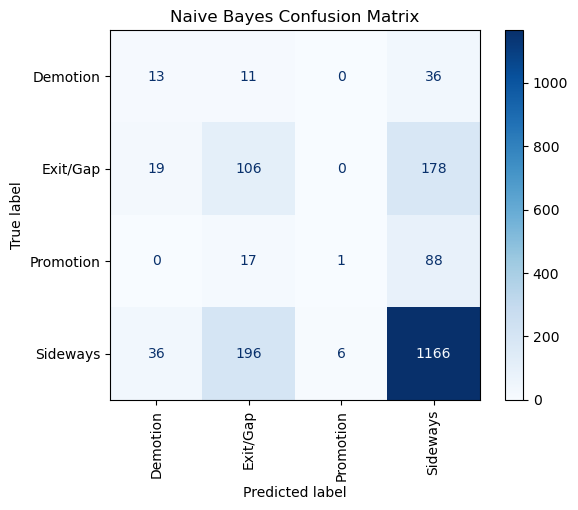

Overall Accuracy: 68.66%

Accuracy by Race (0=White, 1=Black):
Race
0    0.6769
1    0.7123
Name: Correct, dtype: float64

Naive Bayes Bias Summary (% of errors):


Error_Type,Optimistic,Pessimistic
Race,,
0,37.95,62.05
1,48.98,51.02



Top 3 Mispredictions for Black Coaches (Race=1):
Actual     Predicted
Exit/Gap   Sideways     62
Sideways   Exit/Gap     39
Promotion  Sideways     21
dtype: int64

========================= KNN =========================
              precision    recall  f1-score   support

    Demotion       0.18      0.15      0.17        60
    Exit/Gap       0.26      0.15      0.19       303
   Promotion       0.06      0.02      0.03       106
    Sideways       0.76      0.88      0.82      1404

    accuracy                           0.69      1873
   macro avg       0.32      0.30      0.30      1873
weighted avg       0.62      0.69      0.65      1873

CV Macro-F1: 0.3092 ± 0.0074


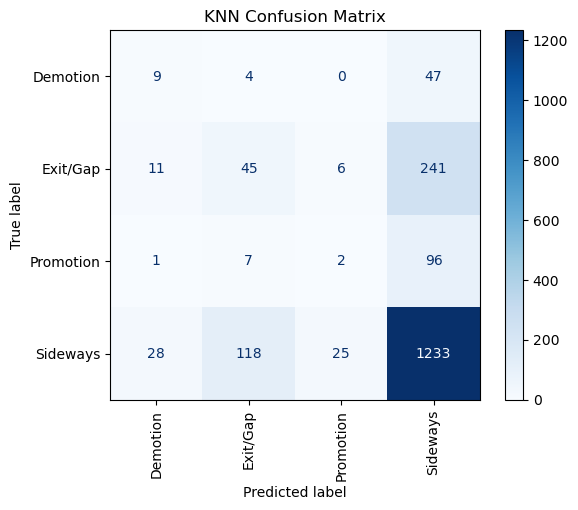

Overall Accuracy: 68.82%

Accuracy by Race (0=White, 1=Black):
Race
0    0.6865
1    0.6928
Name: Correct, dtype: float64

KNN Bias Summary (% of errors):


Error_Type,Optimistic,Pessimistic
Race,,
0,55.27,44.73
1,59.87,40.13



Top 3 Mispredictions for Black Coaches (Race=1):
Actual     Predicted
Exit/Gap   Sideways     80
Sideways   Exit/Gap     28
Promotion  Sideways     24
dtype: int64

========================= LDA =========================
              precision    recall  f1-score   support

    Demotion       0.14      0.08      0.10        60
    Exit/Gap       0.75      0.01      0.02       303
   Promotion       0.00      0.00      0.00       106
    Sideways       0.75      0.98      0.85      1404

    accuracy                           0.74      1873
   macro avg       0.41      0.27      0.24      1873
weighted avg       0.69      0.74      0.65      1873

CV Macro-F1: 0.2602 ± 0.0088


/Users/briankazinduka/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/briankazinduka/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/briankazinduka/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

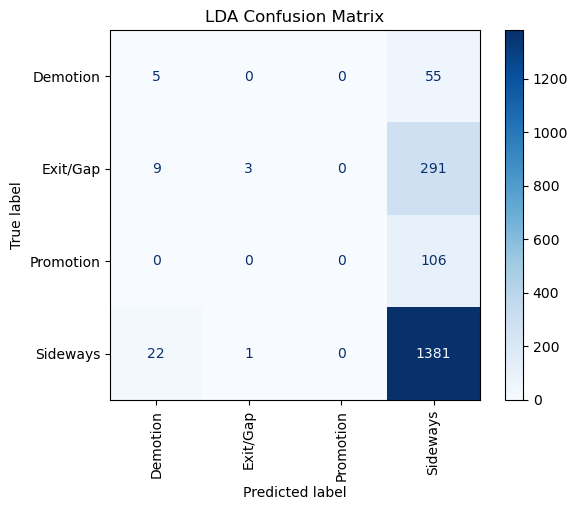

Overall Accuracy: 74.16%

Accuracy by Race (0=White, 1=Black):
Race
0    0.7460
1    0.7299
Name: Correct, dtype: float64

LDA Bias Summary (% of errors):


Error_Type,Optimistic,Pessimistic
Race,,
0,72.83,27.17
1,74.64,25.36



Top 3 Mispredictions for Black Coaches (Race=1):
Actual     Predicted
Exit/Gap   Sideways     91
Promotion  Sideways     25
Sideways   Demotion     10
dtype: int64


In [20]:
# Define models — each wrapped in a Pipeline with the shared preprocessor
model_dict = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "LDA": LinearDiscriminantAnalysis()
}

# Helper: build a full pipeline for each model
def make_pipeline(model):
    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

# Train, evaluate, and audit each model
for name, model in model_dict.items():
    pipe = make_pipeline(model)
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    # Classification report
    print(f"\n{'='*25} {name.upper()} {'='*25}")
    print(classification_report(y_test, preds))
    
    # Cross-validation score
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv_strategy,
                                groups=groups_train, scoring='f1_macro')
    print(f"CV Macro-F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
    
    # Confusion matrix
    disp = ConfusionMatrixDisplay.from_predictions(
        y_test, preds, display_labels=pipe.classes_, cmap='Blues', xticks_rotation='vertical')
    plt.title(f"{name} Confusion Matrix"); plt.show()
    
    # Bias audit
    df_audit = X_test.copy()
    df_audit['Actual'] = y_test
    df_audit['Predicted'] = preds
    df_audit['Correct'] = df_audit['Actual'] == df_audit['Predicted']
    
    print(f"Overall Accuracy: {df_audit['Correct'].mean():.2%}")
    print("\nAccuracy by Race (0=White, 1=Black):")
    print(df_audit.groupby('Race')['Correct'].mean().round(4))
    
    mis = df_audit[~df_audit['Correct']].copy()
    mis['Actual_Rank'] = mis['Actual'].map(rank)
    mis['Predicted_Rank'] = mis['Predicted'].map(rank)
    mis['Error_Type'] = mis.apply(
        lambda r: 'Optimistic' if r['Predicted_Rank'] > r['Actual_Rank'] else 'Pessimistic', axis=1)
    
    print(f"\n{name} Bias Summary (% of errors):")
    bias_table = mis.groupby(['Race', 'Error_Type']).size().unstack(fill_value=0)
    display(bias_table.div(bias_table.sum(axis=1), axis=0).mul(100).round(2))
    
    print("\nTop 3 Mispredictions for Black Coaches (Race=1):")
    top3 = mis[mis['Race'] == 1].groupby(['Actual', 'Predicted']).size().sort_values(ascending=False).head(3)
    print(top3)


# 6c. Addressing Imbalance

--- SCENARIO 1: CLASS WEIGHT BALANCING AUDIT ---

==================== RANDOM FOREST (BALANCED) ====================
              precision    recall  f1-score   support

    Demotion       0.29      0.10      0.15        60
    Exit/Gap       0.28      0.11      0.15       303
   Promotion       0.07      0.02      0.03       106
    Sideways       0.76      0.93      0.83      1404

    accuracy                           0.71      1873
   macro avg       0.35      0.29      0.29      1873
weighted avg       0.63      0.71      0.66      1873

Overall Accuracy: 71.49%
Accuracy by Race (0=White, 1=Black):
Race
0    0.7115
1    0.7241
Name: Correct, dtype: float64

==================== DECISION TREE (BALANCED) ====================
              precision    recall  f1-score   support

    Demotion       0.17      0.15      0.16        60
    Exit/Gap       0.22      0.27      0.24       303
   Promotion       0.11      0.12      0.12       106
    Sideways       0.77      0.73      0.7

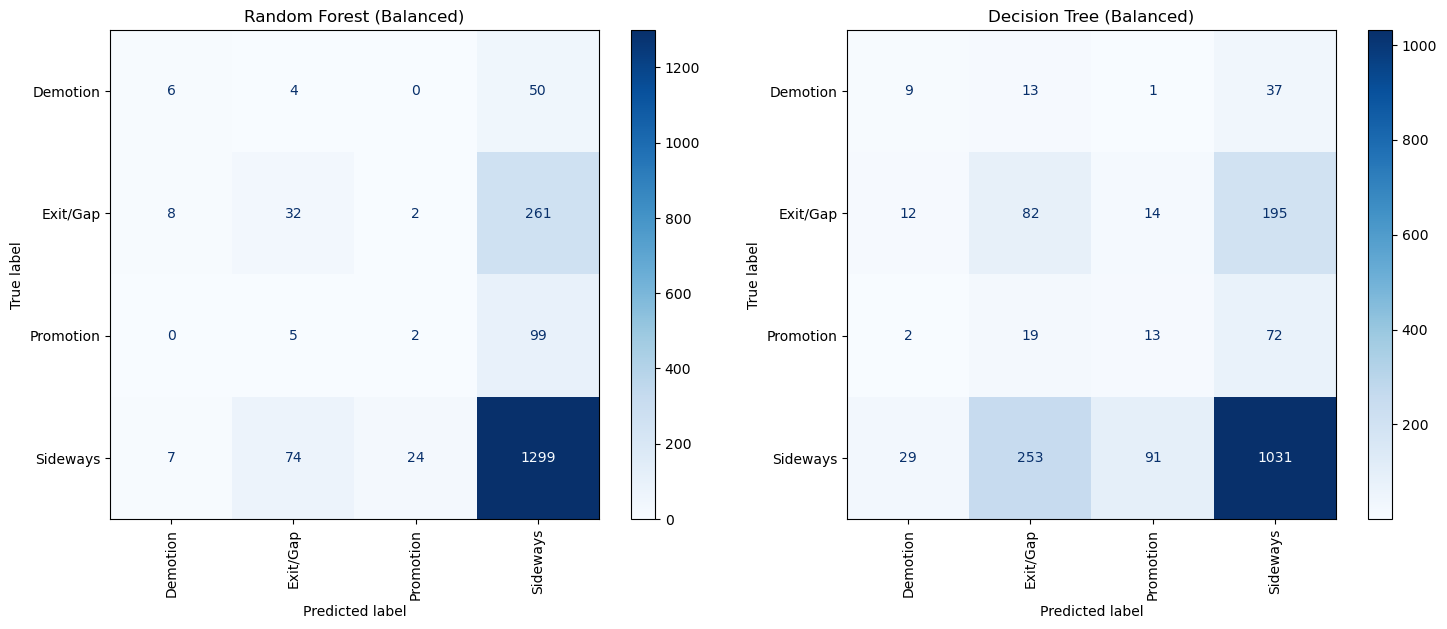


--- SCENARIO 2: SMOTE OVERSAMPLING AUDIT ---

==================== RANDOM FOREST (SMOTE) ====================
              precision    recall  f1-score   support

    Demotion       0.18      0.40      0.25        60
    Exit/Gap       0.28      0.26      0.27       303
   Promotion       0.09      0.08      0.09       106
    Sideways       0.79      0.76      0.78      1404

    accuracy                           0.63      1873
   macro avg       0.34      0.38      0.35      1873
weighted avg       0.65      0.63      0.64      1873

Overall Accuracy: 63.21%
Accuracy by Race (0=White, 1=Black):
Race
0    0.6094
1    0.6928
Name: Correct, dtype: float64

==================== DECISION TREE (SMOTE) ====================
              precision    recall  f1-score   support

    Demotion       0.15      0.30      0.20        60
    Exit/Gap       0.20      0.27      0.23       303
   Promotion       0.07      0.10      0.08       106
    Sideways       0.77      0.65      0.70      14

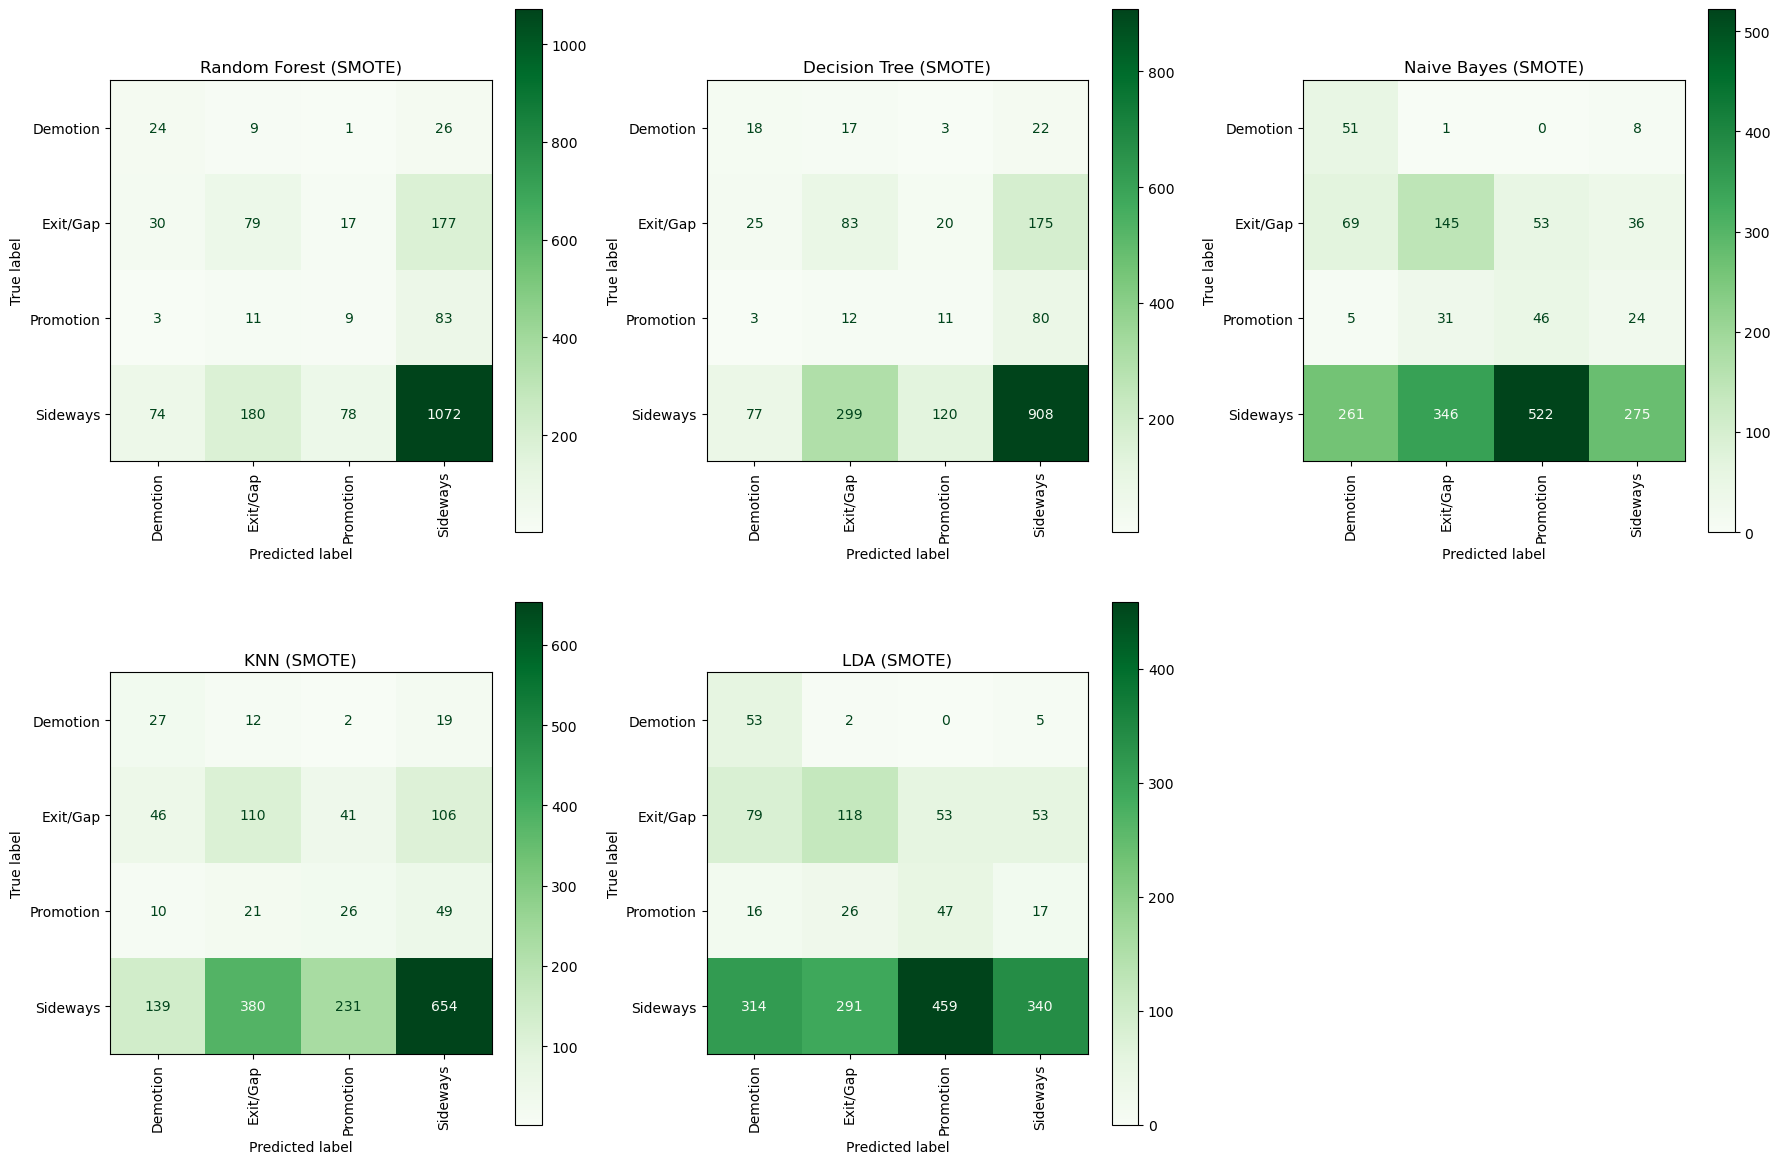

In [21]:
# (plt, ConfusionMatrixDisplay, classification_report, SMOTE/SMOTENC and Pipeline are all
#  imported in the Imports cell — no need to re-import them here.)

balanced_trees = {
    "Random Forest (Balanced)": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "Decision Tree (Balanced)": DecisionTreeClassifier(random_state=42, class_weight='balanced')
}

print("--- SCENARIO 1: CLASS WEIGHT BALANCING AUDIT ---")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for i, (name, model) in enumerate(balanced_trees.items()):
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    
    # 1. Full Classification Report
    print(f"\n{'='*20} {name.upper()} {'='*20}")
    print(classification_report(y_test, preds))
    
    # 2. Accuracy by Race Audit
    df_audit = X_test.copy()
    df_audit['Correct'] = (preds == y_test.values)
    print(f"Overall Accuracy: {df_audit['Correct'].mean():.2%}")
    print("Accuracy by Race (0=White, 1=Black):")
    print(df_audit.groupby('Race')['Correct'].mean().round(4))
    
    ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=axes[i], cmap='Blues', xticks_rotation='vertical')
    axes[i].set_title(name)

plt.tight_layout()
plt.show()

# Pre-transform for SMOTE
X_train_pre = preprocessor.fit_transform(X_train)
X_test_pre = preprocessor.transform(X_test)

# SMOTENC instead of plain SMOTE: Race (0/1) and Tier (ordinal 1-5) are categorical, and
# plain SMOTE interpolates them into meaningless values like Race=0.7 / Tier=3.4. SMOTENC
# leaves those columns at existing category values and only interpolates the genuinely
# continuous stats. Columns 0 and 1 of the transformed matrix are Race and Tier, because the
# ColumnTransformer preserves the order of `features`.
smote = SMOTENC(categorical_features=[0, 1], random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train_pre, y_train)

smote_models = {
    "Random Forest (SMOTE)": RandomForestClassifier(random_state=42),
    "Decision Tree (SMOTE)": DecisionTreeClassifier(random_state=42),
    "Naive Bayes (SMOTE)": GaussianNB(),
    "KNN (SMOTE)": KNeighborsClassifier(n_neighbors=5),
    "LDA (SMOTE)": LinearDiscriminantAnalysis()
}

print("\n--- SCENARIO 2: SMOTE OVERSAMPLING AUDIT ---")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, model) in enumerate(smote_models.items()):
    model.fit(X_resampled, y_resampled)
    preds = model.predict(X_test_pre)
    
    # 1. Full Classification Report
    print(f"\n{'='*20} {name.upper()} {'='*20}")
    print(classification_report(y_test, preds))
    
    # 2. Accuracy by Race Audit
    df_audit_smote = X_test.copy()
    df_audit_smote['Correct'] = (preds == y_test.values)
    print(f"Overall Accuracy: {df_audit_smote['Correct'].mean():.2%}")
    print("Accuracy by Race (0=White, 1=Black):")
    print(df_audit_smote.groupby('Race')['Correct'].mean().round(4))
    
    # display_labels=model.classes_ (was pipe.classes_, a stale leftover from the loop above)
    ConfusionMatrixDisplay.from_predictions(y_test, preds, display_labels=model.classes_,
                                           ax=axes[i], cmap='Greens', xticks_rotation='vertical')
    axes[i].set_title(name)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [22]:
# 1. Update the hierarchy mapping (drop Special Teams, move to a 5-tier scheme)
merged_df = merged_df[merged_df['Role'] != 'ST'].copy()
final_hierarchy = {
    'HC': 5,
    'OC': 4, 'DC': 4,
    'QB': 3,
    'DL': 2, 'WR': 2, 'DB': 2, 'RB': 2,
    'LB': 1, 'OL': 1, 'TE': 1
}

# 2. Re-map Tiers and recompute forward-looking Movement labels
merged_df['Tier'] = merged_df['Role'].map(final_hierarchy)
merged_df = merged_df.sort_values(['CoachID', 'Year'])
merged_df['Next_Tier'] = merged_df.groupby('CoachID')['Tier'].shift(-1)
merged_df['Next_Year'] = merged_df.groupby('CoachID')['Year'].shift(-1)  # refresh: was stale after re-sort
merged_df['Movement'] = merged_df.apply(calculate_forward_movement, axis=1)

# 3. Drop the right-censored final season (labels above were recomputed while it was still
#    present, so 2024 etc. reference the real next season and stay valid; only the
#    unobservable final-season rows themselves are removed).
last_season = merged_df['Year'].max()
model_df = merged_df[merged_df['Year'] < last_season].copy()
print(f"Dropped {len(merged_df) - len(model_df)} right-censored rows from season {last_season}.")

# 4. Re-do the GROUP-AWARE split, then recompute the two pooled features from TRAIN rows only.
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, model_df['Movement'], groups=model_df['CoachID']))
train_df, test_df = add_train_only_features(model_df.iloc[train_idx].copy(),
                                            model_df.iloc[test_idx].copy())

X_train, y_train = train_df[features], train_df['Movement']
X_test,  y_test  = test_df[features],  test_df['Movement']
groups_train = train_df['CoachID']

overlap = set(train_df['CoachID']) & set(test_df['CoachID'])
print("Hierarchy updated to 5 Tiers for Final Evaluation.")
print(f"Coaches in both train & test (should be 0): {len(overlap)}")
print("New Class Distribution (Train):")
print(y_train.value_counts())

Dropped 351 right-censored rows from season 2026.
Hierarchy updated to 5 Tiers for Final Evaluation.
Coaches in both train & test (should be 0): 0
New Class Distribution (Train):
Movement
Sideways     4956
Exit/Gap     1114
Promotion     429
Demotion      288
Name: count, dtype: int64


/var/folders/y5/0nclc89s67qb_6vk8r4sym0c0000gn/T/ipykernel_3194/3767980946.py:39: RuntimeWarning: Mean of empty slice
  d.loc[mask, 'statistical_positionality'] = np.nanmean(np.vstack(ranks), axis=0)


## 7. Hyperparameter Tuning (GridSearchCV)

In [23]:
# Random Forest GridSearch — using pipeline so preprocessing is inside CV
rf_pipeline = make_pipeline(RandomForestClassifier(random_state=42))

# Trimmed grid: 3 x 3 x 2 x 2 x 2 = 72 combos x 5 folds = 360 fits
# (was 9 x 9 x 4 x 8 x 2 = 5,184 combos / 25,920 fits).
# Coarsened the two biggest multipliers (n_estimators, min_samples_leaf), and added
# max_depth=None + min_samples_leaf=1 (sklearn defaults) which the original grid excluded.
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_split': [2, 5],
    'classifier__min_samples_leaf': [1, 4],
    'classifier__class_weight': ['balanced', 'balanced_subsample']
}

print("Running Random Forest GridSearch...")
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=cv_strategy, n_jobs=-1, scoring='f1_macro')
rf_grid.fit(X_train, y_train, groups=groups_train)

print(f"\nBest Parameters: {rf_grid.best_params_}")
print(f"Best CV Macro-F1: {rf_grid.best_score_:.4f}")

Running Random Forest GridSearch...

Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best CV Macro-F1: 0.3796


In [24]:
# Decision Tree GridSearch
dt_pipeline = make_pipeline(DecisionTreeClassifier(random_state=42, class_weight='balanced'))

# Small grid (4 x 2 = 8 combos x 5 folds = 40 fits). The original only tuned max_depth;
# added max_depth=None (unbounded) and a min_samples_leaf dimension so the tree can be
# regularized against overfitting, mirroring the RF search for a fairer comparison.
dt_param_grid = {
    'classifier__max_depth': [5, 10, 20, None],
    'classifier__min_samples_leaf': [1, 4],
}

print("Running Decision Tree GridSearch...")
dt_grid = GridSearchCV(dt_pipeline, dt_param_grid, cv=cv_strategy, n_jobs=-1, scoring='f1_macro')
dt_grid.fit(X_train, y_train, groups=groups_train)

print(f"\nBest Parameters: {dt_grid.best_params_}")
print(f"Best CV Macro-F1: {dt_grid.best_score_:.4f}")

Running Decision Tree GridSearch...

Best Parameters: {'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1}
Best CV Macro-F1: 0.3243


## 8. Final Model Evaluation

Final Optimized Model Performance (Test Set):
              precision    recall  f1-score   support

    Demotion       0.18      0.50      0.27        78
    Exit/Gap       0.31      0.43      0.36       294
   Promotion       0.14      0.16      0.15       139
    Sideways       0.77      0.60      0.67      1200

    accuracy                           0.53      1711
   macro avg       0.35      0.42      0.36      1711
weighted avg       0.61      0.53      0.56      1711



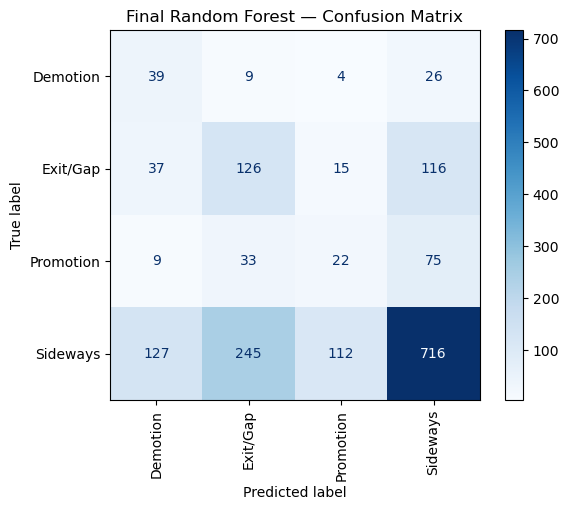


Accuracy by Race (0=White, 1=Black):
Race
0    0.4403
1    0.6575
Name: Correct, dtype: float64

Final Bias Summary (% of errors per group):


Error_Type,Optimistic,Pessimistic
Race,,
0,40.03,59.97
1,34.32,65.68


In [25]:
# Use the best model from grid search
best_model = rf_grid.best_estimator_
final_preds = best_model.predict(X_test)

print("Final Optimized Model Performance (Test Set):")
print(classification_report(y_test, final_preds))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, final_preds, display_labels=best_model.classes_, cmap='Blues', xticks_rotation='vertical')
plt.title("Final Random Forest — Confusion Matrix"); plt.show()

# Final bias audit
df_final = X_test.copy()
df_final['Actual'] = y_test
df_final['Predicted'] = final_preds
df_final['Correct'] = df_final['Actual'] == df_final['Predicted']

print("\nAccuracy by Race (0=White, 1=Black):")
print(df_final.groupby('Race')['Correct'].mean().round(4))

mis = df_final[~df_final['Correct']].copy()
mis['Actual_Rank'] = mis['Actual'].map(rank)
mis['Predicted_Rank'] = mis['Predicted'].map(rank)
mis['Error_Type'] = mis.apply(
    lambda r: 'Optimistic' if r['Predicted_Rank'] > r['Actual_Rank'] else 'Pessimistic', axis=1)

print("\nFinal Bias Summary (% of errors per group):")
bias_table = mis.groupby(['Race', 'Error_Type']).size().unstack(fill_value=0)
display(bias_table.div(bias_table.sum(axis=1), axis=0).mul(100).round(2))


## 9. Feature Importance Analysis

In [26]:
# Extract the classifier from the pipeline
final_rf = best_model.named_steps['classifier']

# MDI importance
mdi = final_rf.feature_importances_

# Permutation importance (on preprocessed test data)
X_test_processed = best_model.named_steps['preprocessor'].transform(X_test)
perm = permutation_importance(final_rf, X_test_processed, y_test,
                               n_repeats=10, random_state=42, n_jobs=-1, scoring='f1_macro')

importance_df = pd.DataFrame({
    'Feature': features,
    'MDI_Importance': mdi,
    'Permutation_Importance': perm.importances_mean,
    'Perm_Std': perm.importances_std
}).sort_values('Permutation_Importance', ascending=False)

print("--- Feature Importance Comparison ---")
display(importance_df.reset_index(drop=True))


--- Feature Importance Comparison ---


,Feature,MDI_Importance,Permutation_Importance,Perm_Std
0,Tier,0.258086,0.062291,0.008874
1,statistical_positionality,0.152202,0.009740,0.008734
2,points_diff,0.131886,0.008400,0.006588
3,Race,0.024684,0.006325,0.003941
4,wins,0.082291,0.005793,0.009574
5,mov,0.060017,-0.000508,0.003298
6,score_pct,0.102987,-0.001534,0.005141
7,prev_league_churn,0.075767,-0.002512,0.004630
8,Experience,0.112079,-0.002815,0.006241


## 10. Fairness Check — Model With vs. Without `Race`

In [27]:
# --- #5: How much does the model lean on Race? Train WITH vs. WITHOUT Race as a feature ---
# Race is both a model input and the axis of the bias audit, which somewhat predetermines the
# audit. Here we retrain the tuned RF configuration with Race removed from the inputs and compare
# overall macro-F1 and per-race accuracy. A small change => the model barely uses Race directly.
# Note: Race is dropped only from the FEATURES; X_test still carries the Race column so we can
# still group the audit by it.
from sklearn.metrics import f1_score

best_params = {k.replace('classifier__', ''): v for k, v in rf_grid.best_params_.items()}

def fit_and_audit(feature_cols, label):
    prep = ColumnTransformer([('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())]), feature_cols)])
    pipe = Pipeline([('preprocessor', prep),
                     ('classifier', RandomForestClassifier(random_state=42, **best_params))])
    pipe.fit(X_train[feature_cols], y_train)
    preds = pipe.predict(X_test[feature_cols])

    macro = f1_score(y_test, preds, average='macro')
    audit = X_test.copy()
    audit['Correct'] = (preds == y_test.values)
    print(f"\n=== {label} ===")
    print(f"Macro-F1: {macro:.4f}")
    print("Accuracy by Race (0=White, 1=Black):")
    print(audit.groupby('Race')['Correct'].mean().round(4))
    return macro

features_no_race = [f for f in features if f != 'Race']
m_with    = fit_and_audit(features,         "WITH Race")
m_without = fit_and_audit(features_no_race, "WITHOUT Race")

print(f"\nMacro-F1 change when Race is removed: {m_without - m_with:+.4f}")
print("(near zero => the model does not rely much on Race as a direct predictor)")


=== WITH Race ===
Macro-F1: 0.3619
Accuracy by Race (0=White, 1=Black):
Race
0    0.4403
1    0.6575
Name: Correct, dtype: float64

=== WITHOUT Race ===
Macro-F1: 0.3623
Accuracy by Race (0=White, 1=Black):
Race
0    0.4648
1    0.5762
Name: Correct, dtype: float64

Macro-F1 change when Race is removed: +0.0004
(near zero => the model does not rely much on Race as a direct predictor)
